In [1]:
import numpy
import matplotlib
import sklearn
import tensorflow

print("All libraries are installed")

All libraries are installed


In [2]:
import pickle
import numpy as np

with open("RML2016.10a_dict.dat", "rb") as f:
    data = pickle.load(f, encoding="latin1")

print(type(data))

<class 'dict'>


In [3]:
print(len(data))
print(list(data.keys())[:5])

220
[('QPSK', 2), ('PAM4', 8), ('AM-DSB', -4), ('GFSK', 6), ('QAM64', 8)]


In [5]:
sample_key = list(data.keys())[0]

signals = data[sample_key]

print(signals.shape)

(1000, 2, 128)


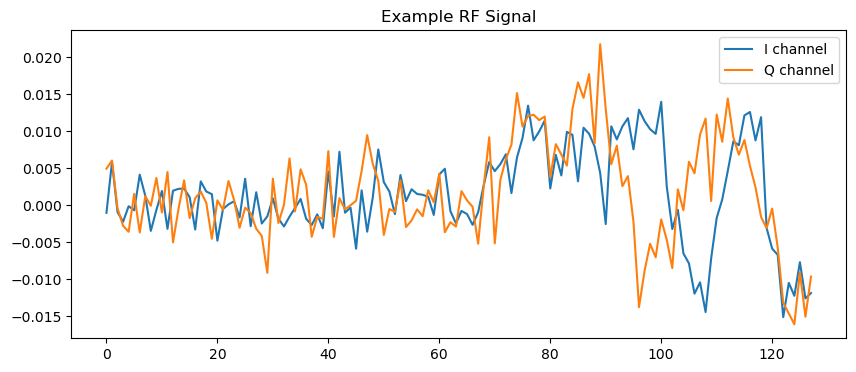

In [6]:
import matplotlib.pyplot as plt

signal = signals[0]

I = signal[0]
Q = signal[1]

plt.figure(figsize=(10,4))
plt.plot(I, label="I channel")
plt.plot(Q, label="Q channel")

plt.legend()
plt.title("Example RF Signal")
plt.show()

In [7]:
X = []
y = []

for mod_snr in data.keys():
    
    mod, snr = mod_snr
    signals = data[mod_snr]

    for signal in signals:
        X.append(signal)
        y.append(mod)

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(220000, 2, 128)
(220000,)


In [8]:
X.shape
y.shape

(220000,)

In [9]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print(y_encoded[:10])

[9 9 9 9 9 9 9 9 9 9]


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(176000, 2, 128)
(44000, 2, 128)


In [12]:
X_train.shape
X_test.shape

(44000, 2, 128)

In [13]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(176000, 2, 128)
(44000, 2, 128)
(176000,)
(44000,)


In [14]:
X_train = X_train.reshape(-1, 2, 128, 1)
X_test = X_test.reshape(-1, 2, 128, 1)

print(X_train.shape)

(176000, 2, 128, 1)


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Dropout

num_classes = len(set(y_encoded))

model = Sequential()

model.add(Conv2D(64, (1,3), activation='relu', input_shape=(2,128,1)))
model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(num_classes, activation='softmax'))

model.summary()

C:\Users\Nabil Dozom\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 2, 126, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16128)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,064,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,066,187 (7.88 MB)

 Trainable params: 2,066,187 (7.88 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 36s 25ms/step - accuracy: 0.2218 - loss: 2.0873 - val_accuracy: 0.2858 - val_loss: 1.9139
Epoch 2/10
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - accuracy: 0.2831 - loss: 1.9185 - val_accuracy: 0.3314 - val_loss: 1.8098
Epoch 3/10
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 34s 24ms/step - accuracy: 0.3022 - loss: 1.8646 - val_accuracy: 0.3362 - val_loss: 1.7816
Epoch 4/10
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - accuracy: 0.3075 - loss: 1.8423 - val_accuracy: 0.3339 - val_loss: 1.7542
Epoch 5/10
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - accuracy: 0.3122 - loss: 1.8296 - val_accuracy: 0.3509 - val_loss: 1.7399
Epoch 6/10
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - accuracy: 0.3198 - loss: 1.8133 - val_accuracy: 0.3561 - val_loss: 1.7176
Epoch 7/10
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.3384 - loss: 1.7765 - val_accuracy: 0.3922 - val_loss: 1.6730
Epoch 8/10
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 36s 26ms/step - accuracy: 0.3580 -

In [18]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

1375/1375 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4145 - loss: 1.5803
Test Accuracy: 0.41447725892066956


In [19]:
predictions = model.predict(X_test)
predicted_labels = predictions.argmax(axis=1)

1375/1375 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


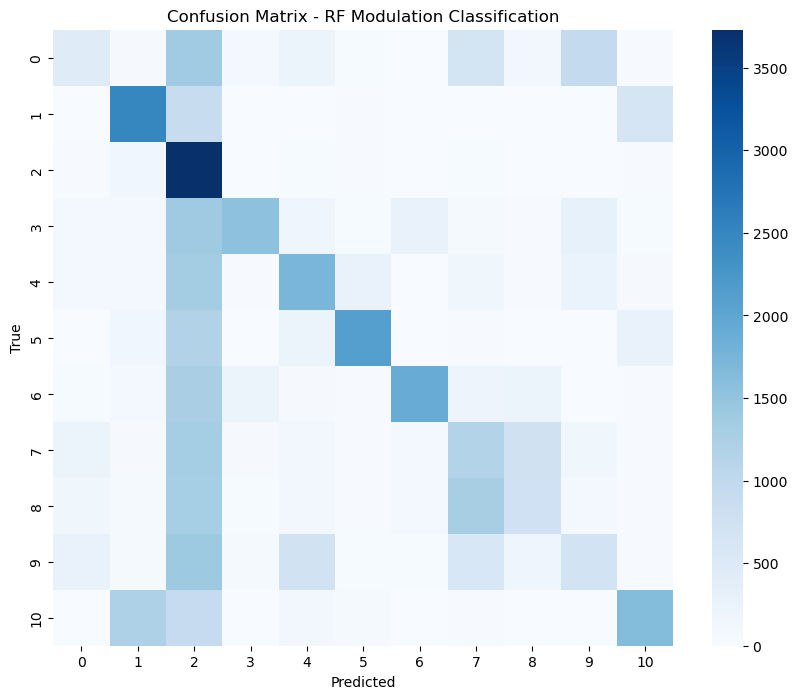

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix - RF Modulation Classification")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [21]:
X = []
y = []

for mod_snr in data.keys():
    
    mod, snr = mod_snr
    
    if snr < 0:
        continue
        
    signals = data[mod_snr]

    for signal in signals:
        X.append(signal)
        y.append(mod)

X = np.array(X)
y = np.array(y)

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Dropout, MaxPooling2D

model = Sequential()

model.add(Conv2D(64, (1,3), activation='relu', input_shape=(2,128,1)))
model.add(MaxPooling2D((1,2)))

model.add(Conv2D(128, (1,3), activation='relu'))
model.add(MaxPooling2D((1,2)))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(num_classes, activation='softmax'))

model.summary()

C:\Users\Nabil Dozom\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 2, 126, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 2, 63, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 2, 61, 128)     │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 30, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,966,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,994,123 (7.61 MB)

 Trainable params: 1,994,123 (7.61 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 53s 37ms/step - accuracy: 0.2691 - loss: 1.9685 - val_accuracy: 0.3831 - val_loss: 1.7111
Epoch 2/10
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 52s 38ms/step - accuracy: 0.3729 - loss: 1.6944 - val_accuracy: 0.4149 - val_loss: 1.5884
Epoch 3/10
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 53s 38ms/step - accuracy: 0.3978 - loss: 1.6247 - val_accuracy: 0.4274 - val_loss: 1.5496
Epoch 4/10
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 52s 38ms/step - accuracy: 0.4135 - loss: 1.5757 - val_accuracy: 0.4443 - val_loss: 1.5037
Epoch 5/10
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 54s 39ms/step - accuracy: 0.4272 - loss: 1.5396 - val_accuracy: 0.4558 - val_loss: 1.4733
Epoch 6/10
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 53s 39ms/step - accuracy: 0.4362 - loss: 1.5144 - val_accuracy: 0.4642 - val_loss: 1.4415
Epoch 7/10
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 53s 39ms/step - accuracy: 0.4439 - loss: 1.4942 - val_accuracy: 0.4736 - val_loss: 1.4256
Epoch 8/10
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 54s 39ms/step - accuracy: 0.4502 -

In [25]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4803 - loss: 1.3930
Test Accuracy: 0.48031818866729736


In [26]:
snrs = sorted(list(set([snr for (mod, snr) in data.keys()])))
print(snrs)

[-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


In [27]:
X = []
y = []

for mod_snr in data.keys():

    mod, snr = mod_snr

    if snr >= 0:   # keep only good signals
        
        signals = data[mod_snr]

        for signal in signals:
            X.append(signal)
            y.append(mod)

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(110000, 2, 128)
(110000,)


In [28]:
X = X.reshape(X.shape[0], 2, 128, 1)

In [29]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

In [31]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test)
)

Epoch 1/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.7065 - loss: 0.6770 - val_accuracy: 0.7464 - val_loss: 0.5387
Epoch 2/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.7138 - loss: 0.6437 - val_accuracy: 0.7565 - val_loss: 0.5346
Epoch 3/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 25s 37ms/step - accuracy: 0.7189 - loss: 0.6226 - val_accuracy: 0.7492 - val_loss: 0.5287
Epoch 4/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 25s 37ms/step - accuracy: 0.7222 - loss: 0.6108 - val_accuracy: 0.7565 - val_loss: 0.5107
Epoch 5/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 26s 37ms/step - accuracy: 0.7248 - loss: 0.5954 - val_accuracy: 0.7645 - val_loss: 0.5007
Epoch 6/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.7282 - loss: 0.5840 - val_accuracy: 0.7654 - val_loss: 0.4858
Epoch 7/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 26s 38ms/step - accuracy: 0.7331 - loss: 0.5731 - val_accuracy: 0.7639 - val_loss: 0.4982
Epoch 8/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 25s 37ms/step - accuracy: 0.7363 - loss: 0.5625 - 

In [32]:
X.shape

(110000, 2, 128, 1)

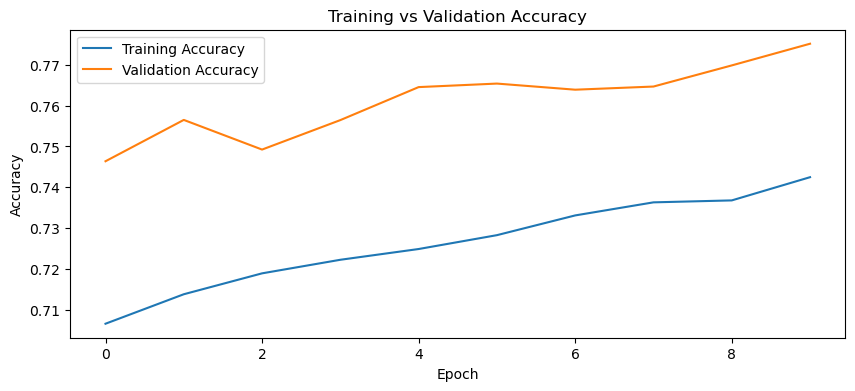

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

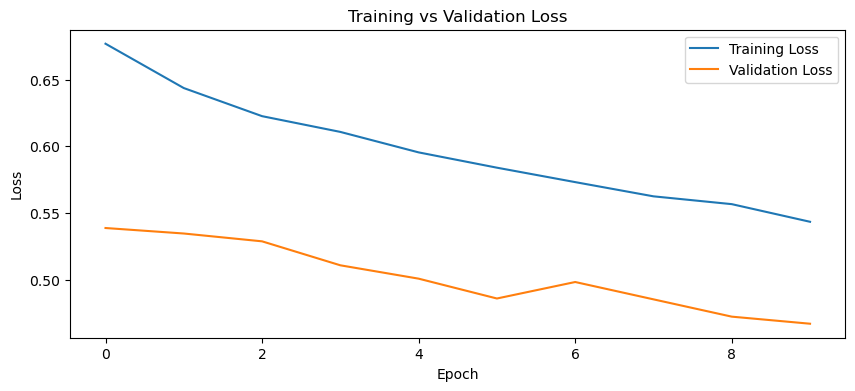

In [34]:
plt.figure(figsize=(10,4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [35]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Final Test Accuracy:", accuracy)

688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7752 - loss: 0.4669
Final Test Accuracy: 0.7751818299293518


In [37]:
predictions = model.predict(X_test)
predicted_labels = predictions.argmax(axis=1)

688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


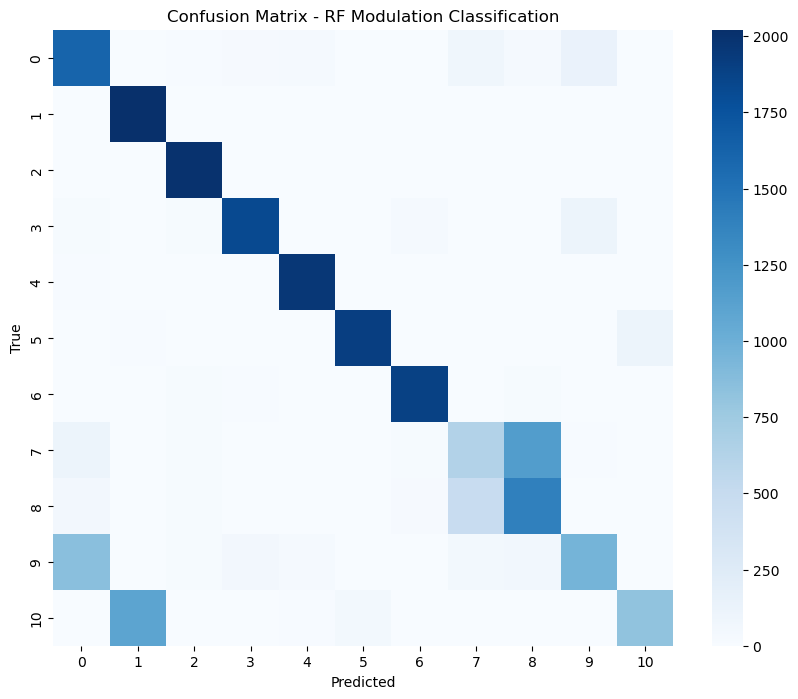

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix - RF Modulation Classification")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [39]:
model.save("RF_modulation_classifier.h5")

In [40]:
sample = X_test[0:1]

prediction = model.predict(sample)
predicted_class = prediction.argmax(axis=1)

print("Predicted class:", predicted_class)
print("Predicted modulation:", encoder.inverse_transform(predicted_class))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted class: [2]
Predicted modulation: ['AM-SSB']


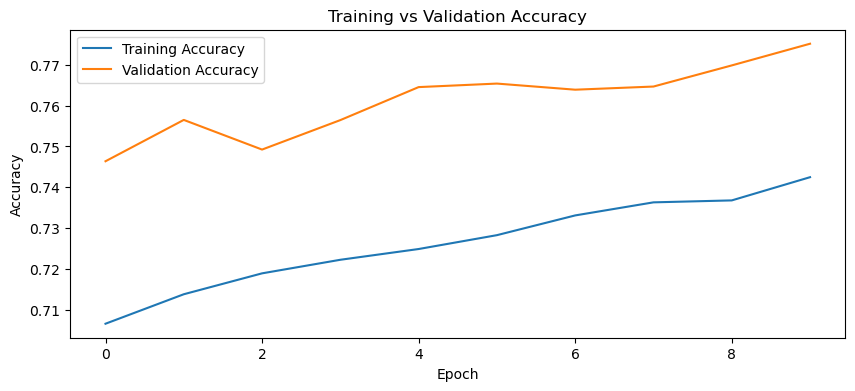

In [41]:
plt.figure(figsize=(10,4))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.savefig("training_accuracy.png")

plt.show()

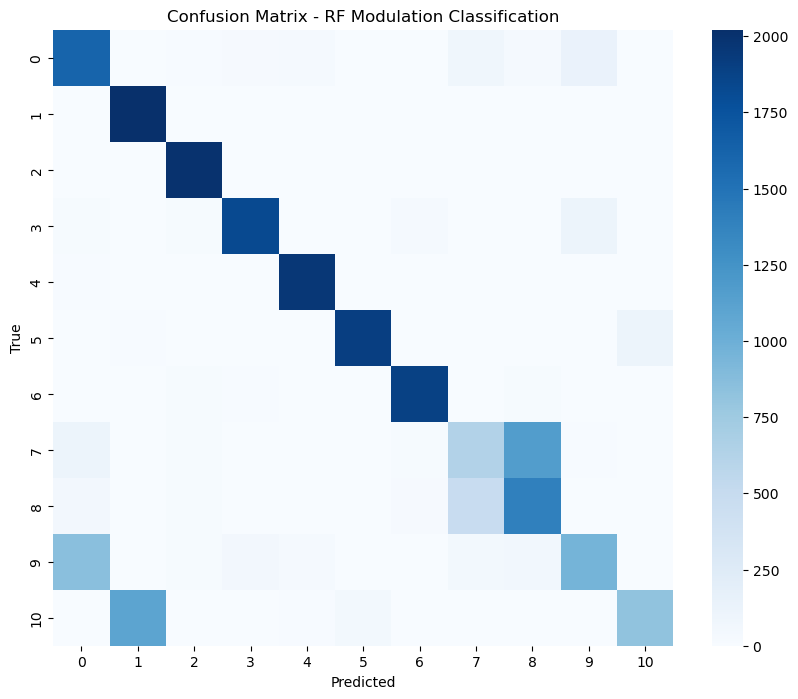

In [42]:
plt.figure(figsize=(10,8))

sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix - RF Modulation Classification")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.savefig("confusion_matrix.png")

plt.show()